# load things for science :)

In [2]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import matplotlib.pyplot
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.cm
import math
import sys
import itertools
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from IPython.display import display, clear_output
import uproot
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from collections import defaultdict

# PID comparison

# load root file (carefully)

In [3]:
branches = [
    'event',
    'w',
    'q2',
    'weight',
    'mm2_mPim',
    'mm2_mPip',
    'mm2_mProt',
    'mm2_excl',
    'pim_mom_miss',
    'pim_mom_meas',
    'pip_mom_miss',
    'pip_mom_meas',
    'prot_mom_miss',
    'prot_mom_meas',
    'excl_mom',
    'pim_theta_miss',
    'pim_theta_meas',
    'pip_theta_miss',
    'pip_theta_meas',
    'prot_theta_miss',
    'prot_theta_meas',
    'pim_theta_angle_btwn_P',
    'pip_theta_angle_btwn_P',
    'prot_theta_angle_btwn_P'
]

In [14]:
# change folder name to 'experiment' or 'simulation' or 'threepion_sim'
folder_name = "simulation"

# options are fall18_inb, fall18_outb, spring19_inb, spring19_inb_noBG, spring19_inb_50nA so far
data_name = "spring19_inb_50nA"

# options include EXCL, mPim
topology_name = "EXCL"

# filename = "/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/experiment/10_2exp_excl_sp19inb_pass2_jlab_07_08_2026_2.root"
filename = "/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/simulation/10_2rec_excl_sp19inb_50nA_jlab_07_17_2026_32threads.root"
tree = uproot.open(filename)["events"]
total_entries = tree.num_entries

# base path for future hists
hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/{folder_name}/{data_name}/{topology_name}_topology')

full_w_edges = np.append(np.arange(1.35, 2.5, 0.05), 2.5)
full_q2_edges = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0]

groups = defaultdict(list)
row_start = 0

total_read = 0
total_kept = 0
total_dropped = 0

with tqdm(total=total_entries, unit="events", desc="Reading ROOT file") as pbar:

    for df in uproot.iterate(f"{filename}:events", branches, library="pd", step_size="500 MB"):

        total_read += len(df)
        pbar.update(len(df))
        before = len(df)
        
        df = df.reset_index(drop=True)
        df["row_id"] = np.arange(row_start, row_start + len(df))
        row_start += len(df)

        df["full_w_bins"] = pd.cut(df["w"], bins=full_w_edges, labels=False, right=False)
        df["full_q2_bins"] = pd.cut(df["q2"], bins=full_q2_edges, labels=False, right=False)

        df = df.dropna(subset=["full_w_bins","full_q2_bins"])

        total_kept += len(df)
        total_dropped += before - len(df)

        for key, group in df.groupby(["full_w_bins","full_q2_bins"]):
            groups[key].append(group)

    for key in groups:
        groups[key] = pd.concat(groups[key], ignore_index=True)

group_total = sum(len(df) for df in groups.values())

print("Total ROOT entries:", tree.num_entries)
print("Total events processed:", total_read)
print("Total events after W/Q² cuts:", total_kept)
print("Events stored in groups:", group_total)



Reading ROOT file:   0%|          | 0/181250322 [00:00<?, ?events/s]

Total ROOT entries: 181250322
Total events processed: 181250322
Total events after W/Q² cuts: 175388844
Events stored in groups: 175388844


In [15]:
threepion_root = uproot.open("/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/simulation/10_2rec_excl_3pi_sp19inb_50nA_jlab_07_27_2026.root")["events"].arrays(library="pd")
threepion_root = threepion_root.reset_index(drop=True)
threepion_root["row_id"] = threepion_root.index

threepion_root["full_w_bins"] = pd.cut(threepion_root["w"], bins=full_w_edges, labels=False, right=False)
threepion_root["full_q2_bins"] = pd.cut(threepion_root["q2"], bins=full_q2_edges, labels=False, right=False)

threepion_root = threepion_root.dropna(subset=["full_w_bins", "full_q2_bins"])
threepion_groups = {}

for key, group in threepion_root.groupby(["full_w_bins", "full_q2_bins"]):
    threepion_groups[key] = group.reset_index(drop=True)

In [16]:
first_events = tree.arrays(branches, entry_start=0, entry_stop=5, library="pd")
print(first_events)

   event         w        q2    weight  mm2_mPim  mm2_mPip  mm2_mProt  \
0      0  2.358092  4.764478  0.000029 -0.074097 -0.557508   0.346849   
1      0  1.459016  4.814035  0.000014  0.003327  0.030341   0.836166   
2      0  2.487836  3.237995  0.000158  0.168745  0.182867   1.400079   
3      0  1.954183  5.885910  0.000011  0.055659  0.143366   1.031203   
4      0  1.285515  6.768840  0.000002 -0.029208 -0.027682   0.760543   

   mm2_excl  pim_mom_miss  pim_mom_meas  ...  excl_mom  pim_theta_miss  \
0  0.020894      0.386745      0.548670  ...  0.253042       96.023140   
1 -0.006021      0.864578      0.734606  ...  0.141857       29.740255   
2 -0.000775      0.702956      0.460998  ...  0.333682       23.971312   
3 -0.002708      0.784114      0.659942  ...  0.153396       24.975252   
4 -0.007060      0.638058      0.683027  ...  0.117683       34.341255   

   pim_theta_meas  pip_theta_miss  pip_theta_meas  prot_theta_miss  \
0       73.577042       11.299251       11.739

In [17]:
last_events = tree.arrays(branches, entry_start=tree.num_entries-5, entry_stop=tree.num_entries, library="pd")
print(last_events)

           event         w         q2        weight  mm2_mPim  mm2_mPip  \
181250317  32598  2.130060   9.495250  4.132000e-06 -0.140660 -0.062131   
181250318  32598  1.916818   3.793964  3.381320e-05 -0.003269  0.058021   
181250319  32598  1.368962  11.015682  3.223000e-07 -0.047451 -0.014385   
181250320  32598  2.309761   5.232787  3.119340e-05  0.018001  0.005470   
181250321  32598  2.014406   7.420063  3.250200e-06  0.362897  0.046341   

           mm2_mProt  mm2_excl  pim_mom_miss  pim_mom_meas  ...  excl_mom  \
181250317   0.766501  0.000229      4.434829      4.518211  ...  0.100291   
181250318   0.878259 -0.012043      1.100664      1.008745  ...  0.136292   
181250319   0.729452 -0.002942      1.066207      1.080049  ...  0.070676   
181250320   0.846943 -0.000037      2.098113      2.127266  ...  0.030068   
181250321   1.256695 -0.013880      2.111785      1.874405  ...  0.337654   

           pim_theta_miss  pim_theta_meas  pip_theta_miss  pip_theta_meas  \
181250317

In [18]:
print(len(threepion_root))
print(threepion_root.head())

6919
   event         w        q2    weight  pid_prot_rec  pid_pip_rec  \
0      0  1.749529  2.904576  0.021026          2212          211   
1      0  2.416227  3.821020  0.085943          2212          211   
2      0  2.387862  4.555152  0.049843          2212          211   
3      0  2.068242  7.223691  0.100787          2212          211   
4      0  1.696150  7.449101  0.061727          2212          211   

   pid_pim_rec  pid_prot_mc  pid_pip_mc  pid_pim_mc  ...  pip_theta_miss  \
0         -211          211         211        -211  ...        7.691428   
1         -211         -211         211        -211  ...       39.662907   
2         -211         -999         211          11  ...       19.141447   
3         -211         -999         211        -211  ...       12.967484   
4         -211         -211         211        -211  ...       41.660358   

   pip_theta_meas  prot_theta_miss  prot_theta_meas  pim_theta_angle_btwn_P  \
0       39.747765        10.270171        40

In [19]:
print(threepion_root.tail())

      event         w        q2    weight  pid_prot_rec  pid_pip_rec  \
7448      0  2.291635  8.217970  0.088710          2212          211   
7449      0  1.737357  2.399347  0.033045          2212          211   
7450      0  1.708450  3.576461  0.010819          2212          211   
7451      0  1.994580  3.365943  0.040716          2212          211   
7452      0  1.933337  2.009780  0.033220          2212          211   

      pid_pim_rec  pid_prot_mc  pid_pip_mc  pid_pim_mc  ...  pip_theta_miss  \
7448         -211          211         211        -211  ...       13.254224   
7449         -211          211         211        -211  ...       24.508343   
7450         -211          211         211        -211  ...        6.418926   
7451         -211          211         211        -211  ...       27.185894   
7452         -211          211        -211        -211  ...       25.794346   

      pip_theta_meas  prot_theta_miss  prot_theta_meas  \
7448       48.601971        17.684

In [20]:
print(len(df))
print(df["mm2_mPim"].notna().sum())
print(df["pim_theta_angle_btwn_P"].notna().sum())
print(df["pim_mom_miss"].notna().sum())
print(df["pim_mom_meas"].notna().sum())

4042336
4042336
4042336
4042336
4042336


In [21]:
w_min = df["w"].min()
w_max = df["w"].max()

q2_min = df["q2"].min()
q2_max = df["q2"].max()
    
print("w min:", w_min)
print("w max:", w_max)
print("q2 min:", q2_min)
print("q2 max:", q2_max)


w min: 1.35
w max: 2.4999998
q2 min: 1.6003753
q2 max: 11.999978


In [22]:
bins_value = 100
step = 0.001

# # --- Define MM² ranges for each topology ---
# topologies = {
#     "excl": (-0.03, 0.03),
#     "mProt": (-0.1, 2.5),
#     "mPip": (-0.4, 0.6),
#     "mPim": (-0.4, 0.6),
# }

# w-q2 range

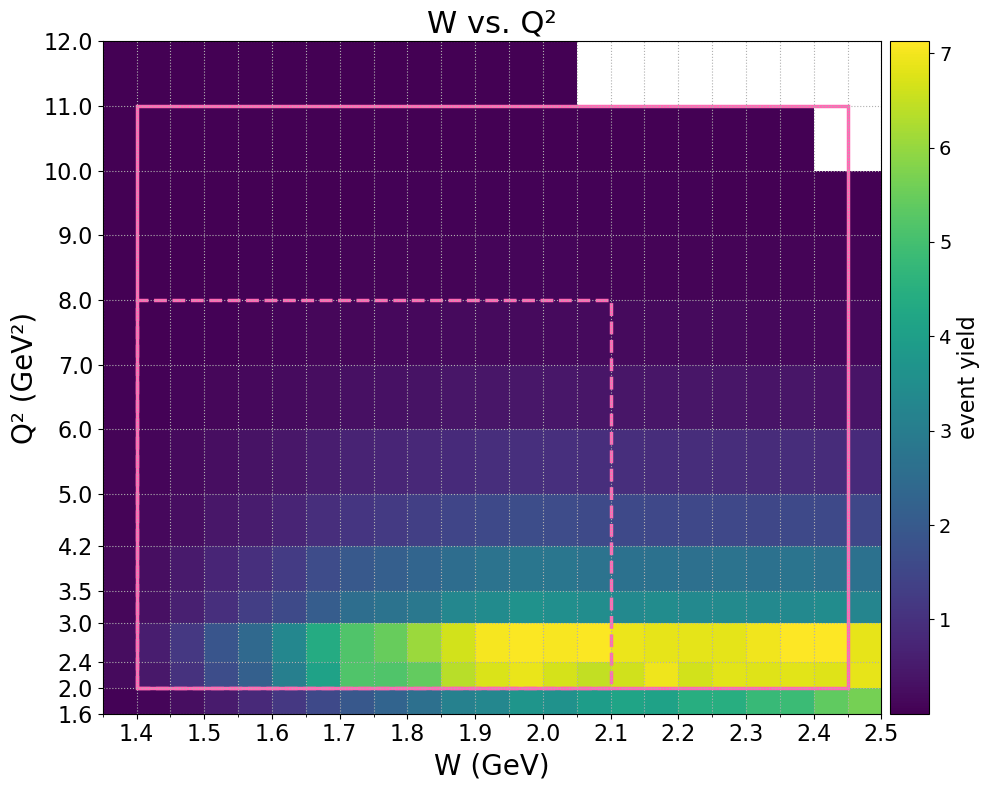

In [23]:
# Define which dataset to visualize
dataset = df 

w_range = np.append(np.arange(1.35, 2.5, 0.05), 2.5)
q2_range = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0]

w_min, w_max   = 1.35, 2.50
q2_min, q2_max = 1.6, 12.0

# --- W vs Q² histograms with colorbars for each topology ---
# Define bin edges from your ranges
bin_x = w_range
bin_y = q2_range

# for topo in topologies:
fig, ax = plt.subplots(figsize=(10, 8))
mask = dataset["w"].notna() & dataset["q2"].notna()
w_vals = dataset.loc[mask, "w"].to_numpy()
q2_vals = dataset.loc[mask, "q2"].to_numpy()
weights = dataset.loc[mask, "weight"].to_numpy()

# 2D histogram — color represents event density
h = ax.hist2d(w_vals, q2_vals, bins=[bin_x, bin_y], cmap='viridis', cmin=1e-12, weights=weights, density=False)

# Title and axes
ax.set_title(f"W vs. Q²", fontsize=22)
ax.set_xlabel("W (GeV)", fontsize=20)
ax.set_ylabel("Q² (GeV²)", fontsize=20)

# Colorbar setup
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h[3], cax=cax)
cb.set_label("event yield", fontsize=16)
cb.ax.tick_params(labelsize=14)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(bin_x, minor=True) 
ax.set_yticks(bin_y)

# Define analyzed range
w_min_analyzed, w_max_analyzed = 1.4, 2.45
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

# Create a red rectangle
rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),  # bottom-left corner
    w_max_analyzed - w_min_analyzed,    # width
    q2_max_analyzed - q2_min_analyzed,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, facecolor='none')

# Define analyzed range
w_min_analyzed_krishna, w_max_analyzed_krishna = 1.4, 2.10
q2_min_analyzed_krishna, q2_max_analyzed_krishna = 2.0, 8.0

# Create a red rectangle
rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),  # bottom-left corner
    w_max_analyzed_krishna - w_min_analyzed_krishna,    # width
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, linestyle='--', facecolor='none')

# Add rectangle to the axes
ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

# w-q2 binned cuts

In [13]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,13.0]

# Create only the bins you actually want to plot
plot_groups = {}

for group in groups.values():

    group = group.copy()

    group["w_bin"] = pd.cut(group["w"], bins=w_bins, labels=False, right=False)
    group["q2_bin"] = pd.cut(group["q2"], bins=q2_bins, labels=False, right=False)

    group = group.dropna(subset=["w_bin", "q2_bin"])

    for key, sub_group in group.groupby(["w_bin", "q2_bin"]):
        plot_groups[key] = sub_group

In [14]:
# --- Initialize cut_results for all systematic cuts ---
cut_results = {
    "mm2": {"in": {}, "out": {}, "all": {}},
    "theta": {"in": {}, "out": {}, "all": {}},
    "momentum": {"in": {}, "out": {}, "all": {}}
}

## mm2 cuts

In [15]:
binned_hist_path = Path("MM2_binned_wq2/mm2_cuts")

# --- Gaussian function ---
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# --- Define MM² topologies ---
topologies_mm2 = {
    "excl":  {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    "mProt": {"range": (-0.1, 2.5),   "fit_window": (0.4, 1.25)},
    # "mPip":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    "mPip":  {"range": (-0.2, 0.2),   "fit_window": (-0.2, 0.2)},
    "mPim":  {"range": (-0.2, 0.25),   "fit_window": (-0.2, 0.25)},
    # "mPim":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    # "mPim":  {"range": (-2.0, 0.6),   "fit_window": (-0.3, 0.2)},
}

# --- Bin the data ---
df['w_bin'] = pd.cut(df['w'], bins=w_bins, labels=False, right=False)
df['q2_bin'] = pd.cut(df['q2'], bins=q2_bins, labels=False, right=False)
binned_data = df.dropna(subset=['w_bin', 'q2_bin'])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    if bin_idx < len(bin_edges) - 1:
        return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"
    return "[out of range)"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

sigma_factors = [
    (-1.25,  1.25),
    (-1.5,  2.0),
    (-4.0,  4.5),
]

USE_MANUAL_COLORS = True

if USE_MANUAL_COLORS:
    sigma_colors = [
        "limegreen",
        "magenta",
        "darkviolet",
        # "orange",
    ]
else:
    cmap = plt.cm.rainbow_r
    sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# --- Process a single (W,Q2) bin ---
def process_bin(group, w_bin, q2_bin, topo, sigma=1.1775):
    """Process a single (w,q2) bin with Gaussian fit cuts for a given MM² topology."""
    w_label = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)
    column = f"mm2_{topo}"
    x_min, x_max = topologies_mm2[topo]["range"]

    # Histogram over plotting range
    values, bins = np.histogram(group[column].dropna(), bins=bins_value, range=(x_min, x_max))
    bin_centers = (bins[:-1] + bins[1:]) / 2.0

    # Number of events actually included in the histogram
    n_events = values.sum()

    # initialize fit & cut results
    amp_fit = mean_fit = sigma_fit = None
    left_out = right_out = left_in = right_in = None

    try:
        # --- get user-provided fit window (must be tuple (left, right)) ---
        fit_window = topologies_mm2[topo].get("fit_window", None)
        if fit_window is None:
            raise ValueError(f"No fit_window defined for topology '{topo}'")

        if not (isinstance(fit_window, tuple) and len(fit_window) == 2):
            raise ValueError(f"fit_window for '{topo}' must be a tuple (left, right)")

        fit_window_left, fit_window_right = fit_window

        # --- Restrict fit mask to the intersection of fit_window and plotting range ---
        fit_mask = (bin_centers >= fit_window_left) & (bin_centers <= fit_window_right)

        # If there are no bins inside the fit window, expand to nearest valid bins inside plotting range
        if not np.any(fit_mask):
            # find bins inside plotting range and attempt small fallback (use full plotting range)
            fit_mask = (bin_centers >= x_min) & (bin_centers <= x_max)
            if not np.any(fit_mask):
                raise ValueError("No histogram bins in plotting range to fit.")

        # --- Find peak inside fit window (local peak) ---
        local_values = values[fit_mask]
        local_centers = bin_centers[fit_mask]

        # If all zeros, raise to fallback
        if local_values.sum() == 0:
            raise ValueError("No counts in fit window to determine peak.")

        local_peak_idx = np.argmax(local_values)
        # convert local index back to global index in bin_centers
        global_peak_idx = np.where(fit_mask)[0][local_peak_idx]
        peak_x = bin_centers[global_peak_idx]

        # --- Prepare fit arrays (only inside fit window) ---
        x_fit = local_centers
        y_fit = local_values

        # require at least 3 points to fit a Gaussian robustly
        if len(x_fit) < 3 or y_fit.sum() == 0:
            raise ValueError("Insufficient points in fit window for Gaussian fit.")

        # initial guesses
        amp_guess = float(y_fit.max())
        mean_guess = float(peak_x)
        sigma_guess = max(1e-6, 0.25 * (fit_window_right - fit_window_left))  # avoid zero

        # --- Fit Gaussian only on the fit window data ---
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[amp_guess, mean_guess, sigma_guess], maxfev=20000)
        amp_fit, mean_fit, sigma_fit = popt

        for i, (left_sigma, right_sigma) in enumerate(sigma_factors):

            left  = mean_fit + left_sigma * sigma_fit
            right = mean_fit + right_sigma * sigma_fit

            inside_df = group.loc[group[column].between(left, right), ["row_id"]]
            outside_df = group.loc[~group[column].between(left, right), ["row_id"]]

            cut_results.setdefault("mm2", {}).setdefault("in", {})[
                (w_bin, q2_bin, topo, left_sigma, right_sigma)
            ] = inside_df

            cut_results.setdefault("mm2", {}).setdefault("out", {})[
                (w_bin, q2_bin, topo, left_sigma, right_sigma)
            ] = outside_df

        # all_df = group.copy()
        all_df = group[["row_id", column]].copy()
        
        cut_results.setdefault("mm2", {}).setdefault("all", {})[(w_bin, q2_bin, topo)] = all_df

    except Exception as e:
        print(f"Skipping bad bin -> {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")
        return
    
    cut_results.setdefault("mm2", {}).setdefault("fit", {})[(w_bin, q2_bin, topo)] = {"mean": mean_fit, "sigma": sigma_fit}

    # --- Plot results ---
    plt.figure(figsize=(11, 7))
    plt.hist(group[column].dropna(), bins=bins_value, range=(x_min, x_max), label=f"all events (N={n_events:,})", alpha=0.8, color='black', histtype='step', linewidth=0.8)

    # Plot fitted Gaussian only if fit succeeded
    if amp_fit is not None and sigma_fit is not None and mean_fit is not None:
        # plot Gaussian only over the fit window (dense sampling)
        x_dense = np.linspace(max(x_min, fit_window_left), min(x_max, fit_window_right), 1000)
        y_dense = gaussian(x_dense, amp_fit, mean_fit, sigma_fit)
        plt.plot(x_dense, y_dense, color='blue', alpha=0.6, linewidth=1.0, label='gaussian fit')

        # vertical line at fit mean
        plt.axvline(mean_fit, color='blue', linestyle='--', alpha=0.6, linewidth=1.0, label=f'peak fit = {mean_fit:.4f}')

    else:
        # if fit failed, optionally mark the fit window region for debugging
        try:
            plt.axvspan(fit_window_left, fit_window_right, color='gray', alpha=0.08, label='fit window')
        except Exception:
            pass

    # --- Plot multiple in-cuts ---
    # for i, sigma in enumerate(sigma_factors):
    #     left = mean_fit - sigma * sigma_fit
    #     right = mean_fit + sigma * sigma_fit

    #     # Number of events inside this cut
    #     n_inside = group[column].between(left, right).sum()

    #     color = sigma_colors[i]
    #     lw = 1.2
    #     alpha = 0.9

    #     plt.axvline(left,  color=color, linestyle='-', linewidth=lw, alpha=alpha)
    #     plt.axvline(right, color=color, linestyle='-', linewidth=lw, alpha=alpha)
    #     plt.plot([], [], color=color, linestyle='-', linewidth=lw, alpha=alpha, label=f'±{sigma:.2f}σ (N={n_inside:,})')

    for i, (left_sigma, right_sigma) in enumerate(sigma_factors):

        left  = mean_fit + left_sigma * sigma_fit
        right = mean_fit + right_sigma * sigma_fit

        # Number of events inside this cut
        n_inside = group[column].between(left, right).sum()

        color = sigma_colors[i]
        lw = 1.2
        alpha = 0.9

        plt.axvline(left, color=color, linestyle='-', linewidth=lw, alpha=alpha)
        plt.axvline(right, color=color, linestyle='-', linewidth=lw, alpha=alpha)

        plt.plot([], [], color=color, linestyle='-', linewidth=lw, alpha=alpha, label=f'{left_sigma:+.2f}σ to {right_sigma:+.2f}σ (N={n_inside:,})')

    # Title & labels
    plt.title(f"{topo} MM²: W {w_label}, Q² {q2_label}", fontsize=25)
    plt.xlabel('MM² [GeV²]', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=14, loc='upper left')

    # Save figure
    outdir = hist_base_path / binned_hist_path / f"mm2cuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)
    fname = outdir / f"mm2_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop over MM² topologies ---
for topo in topologies_mm2:
    # total_bins = binned_data.groupby(['w_bin', 'q2_bin']).ngroups
    total_bins = len(plot_groups)
    # for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(['w_bin', 'q2_bin']), start=1):
    for i, ((w_bin,q2_bin), group) in enumerate(plot_groups.items(), start=1):
        process_bin(group, int(w_bin), int(q2_bin), topo, sigma=3.0)
        print(f"{topo}: Saved histogram {i}/{total_bins} ({i/total_bins*100:.2f}% complete)", end="\r")
        sys.stdout.flush()
    print()  # new line after each topo

Skipping bad bin -> excl, W-bin 17, Q2-bin 10: No counts in fit window to determine peak.
excl: Saved histogram 238/238 (100.00% complete)
Skipping bad bin -> mProt, W-bin 4, Q2-bin 10: Optimal parameters not found: Number of calls to function has reached maxfev = 20000.
Skipping bad bin -> mProt, W-bin 17, Q2-bin 10: No counts in fit window to determine peak.
mProt: Saved histogram 238/238 (100.00% complete)
Skipping bad bin -> mPip, W-bin 17, Q2-bin 10: No counts in fit window to determine peak.
mPip: Saved histogram 238/238 (100.00% complete)
Skipping bad bin -> mPim, W-bin 17, Q2-bin 10: No counts in fit window to determine peak.
mPim: Saved histogram 238/238 (100.00% complete)


## theta cuts

In [33]:
binned_hist_path = Path("MM2_binned_wq2/theta_cuts")

# --- Define topologies ---
topologies_theta = {
    "prot": {"column": "prot_theta_angle_btwn_P", "range": (-1, 25)},
    "pip": {"column": "pip_theta_angle_btwn_P", "range": (-1, 25)},
    "pim": {"column": "pim_theta_angle_btwn_P", "range": (-1, 25)},
}

# --- Bin the data ---
df['w_bin'] = pd.cut(df['w'], bins=w_bins, labels=False, right=False)
df['q2_bin'] = pd.cut(df['q2'], bins=q2_bins, labels=False, right=False)
binned_data = df.dropna(subset=['w_bin', 'q2_bin'])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    if bin_idx < len(bin_edges) - 1:
        return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"
    return "[out of range)"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

# theta_sigma_factors = np.arange(-0.5, 2.00 + 0.001, 0.5)
theta_sigma_factors = (0.25, 1.5, 4.0) #, 3.0)

# --- Histogram-based FWHM estimation ---
def estimate_fwhm(data, bins=200, range=None):
    hist, edges = np.histogram(data, bins=bins, range=range)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    if hist.sum() == 0:
        return None

    # --- Find peak ---
    peak_idx = np.argmax(hist)
    peak_y = hist[peak_idx]
    half_max = peak_y / 2.0

    # --- Find right side where hist falls below half max ---
    right_idx = np.where(hist[peak_idx:] < half_max)[0]
    if len(right_idx) == 0:
        return None

    right_edge = bin_centers[peak_idx + right_idx[0]]
    fwhm = 2 * (right_edge - bin_centers[peak_idx])  # approximate FWHM

    return {
        "mu": bin_centers[peak_idx],
        "fwhm": fwhm,
        "x": bin_centers,
        "y": hist,
    }

# --- Process a single bin ---
def process_bin(group, w_bin, q2_bin, topo): #, sigma_in_factor=1.1775, sigma_out_factor=1.1775):
    w_label = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)
    column = topologies_theta[topo]["column"]
    x_min, x_max = topologies_theta[topo]["range"]
    fit_res = estimate_fwhm(group[column], bins=bins_value, range=(x_min, x_max))

    if fit_res is None:
        return
    
    mu = fit_res["mu"]
    fwhm = fit_res["fwhm"]
    sigma = fwhm / 2.355
    # all_df = group.copy()

    for sigma_in in theta_sigma_factors:
        right_in = mu + sigma_in * sigma

        inside_df = group.loc[group[column] <= right_in, ["row_id"]]
        outside_df = group.loc[group[column] > right_in, ["row_id"]]

        cut_results.setdefault("theta", {}).setdefault("in", {})[(w_bin, q2_bin, topo, sigma_in)] = inside_df
        cut_results.setdefault("theta", {}).setdefault("out", {})[(w_bin, q2_bin, topo, sigma_in)] = outside_df
        # cut_results.setdefault("theta", {}).setdefault("all", {})[(w_bin, q2_bin, topo, sigma_in)] = all_df

    # --- Plot ---
    # Number of events that are actually included in the histogram
    hist_counts, _ = np.histogram(
        group[column],
        bins=bins_value,
        range=(x_min, x_max)
    )
    n_hist = hist_counts.sum()

    plt.figure(figsize=(11, 7))
    plt.hist(group[column], bins=bins_value, range=(x_min, x_max), alpha=0.8, color='black', histtype='step', linewidth=0.8, label=f"all events (N={n_hist})")

    USE_MANUAL_COLORS = True

    if USE_MANUAL_COLORS:
        sigma_colors = [
            "limegreen",
            "magenta",
            "darkviolet",
        ]
    else:
        cmap = plt.cm.rainbow_r
        sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

    for i, sigma_in in enumerate(theta_sigma_factors):
        right = mu + sigma_in * sigma
        colors = sigma_colors[i]

        n_inside = (group[column] <= right).sum()
        frac_inside = 100 * n_inside / len(group)

        plt.axvline(right, color=colors, linewidth=1.2, label=f"≤ {sigma_in:.2f}σ (N={n_inside:,})") #, {frac_inside:.1f}%)")
        # plt.axvline(right, color=colors, linewidth=1.2, label=f"inside cut ≤ {sigma_in:.2f}σ")

    plt.title(fr"{topo} θ btwn $P_{{miss}}$ and $P_{{meas}}$: W {w_label}, Q² {q2_label}", fontsize=25)
    plt.xlabel('θ (degrees)', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=14)

    outdir = hist_base_path / binned_hist_path / f"thetacuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)
    fname = outdir / f"theta_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop ---
for topo in topologies_theta:
    # total_bins = binned_data.groupby(['w_bin', 'q2_bin']).ngroups
    total_bins = len(plot_groups)
    # for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(['w_bin', 'q2_bin']), start=1):
    for i, ((w_bin,q2_bin), group) in enumerate(plot_groups.items(), start=1):
        process_bin(group, int(w_bin), int(q2_bin), topo) #, sigma_in_factor=4.75, sigma_out_factor=0.375)
        print(f"{topo}: Saved histogram {i}/{total_bins} ({i/total_bins*100:.2f}% complete)", end="\r")
        sys.stdout.flush()
    print()

prot: Saved histogram 238/238 (100.00% complete)
pip: Saved histogram 238/238 (100.00% complete)
pim: Saved histogram 238/238 (100.00% complete)


## momentum cuts

In [18]:
binned_hist_path = Path("MM2_binned_wq2/momentum_cuts")

# --- Gaussian function ---
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# --- Sigma values ---
# mom_sigma_factors = np.arange(0.5, 2.5 + 0.001, 1.0) 
mom_sigma_factors = (1.0, 2.0, 4.0) 

# --- Define topologies ---
topologies_momentum = {
    "prot": {"missing": "prot_mom_miss", "measured": "prot_mom_meas", "range": (-1, 2)},
    "pip":  {"missing": "pip_mom_miss",  "measured": "pip_mom_meas",  "range": (-1, 2)},
    "pim":  {"missing": "pim_mom_miss",  "measured": "pim_mom_meas",  "range": (-1, 2)},
}

# --- Bin the data ---
df["w_bin"]  = pd.cut(df["w"],  bins=w_bins,  labels=False, right=False)
df["q2_bin"] = pd.cut(df["q2"], bins=q2_bins, labels=False, right=False)
binned_data = df.dropna(subset=["w_bin", "q2_bin"])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

# --- Process one (W, Q²) bin ---
def process_momentum_bin(group, w_bin, q2_bin, topo):
    w_label  = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)

    missing_col  = topologies_momentum[topo]["missing"]
    measured_col = topologies_momentum[topo]["measured"]
    x_min, x_max = topologies_momentum[topo]["range"]

    mom_diff = group[missing_col] - group[measured_col]

    # --- Histogram ---
    values, bins = np.histogram(mom_diff, bins=bins_value, range=(x_min, x_max))
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Number of events actually included in histogram range
    n_events = values.sum()

    try:
        # --- Fit range (important for stability) ---
        fit_min, fit_max = -0.5, 0.3
        mask  = (bin_centers >= fit_min) & (bin_centers <= fit_max)
        fit_x = bin_centers[mask]
        fit_y = values[mask]

        # --- Initial guess ---
        peak_idx   = np.argmax(values)
        amp_guess  = values[peak_idx]
        mean_guess = bin_centers[peak_idx]
        sigma_guess = 0.1

        popt, _ = curve_fit(gaussian, fit_x, fit_y, p0=[amp_guess, mean_guess, sigma_guess], maxfev=5000)
        amp_fit, mean_fit, sigma_fit = popt

        # --- Multi-sigma cuts ---
        for sigma in mom_sigma_factors:
            left  = mean_fit - sigma * sigma_fit
            right = mean_fit + sigma * sigma_fit

            inside_df = group.loc[mom_diff.between(left, right), ["row_id"]]
            outside_df = group.loc[~mom_diff.between(left, right), ["row_id"]]

            cut_results["momentum"]["in"][(w_bin, q2_bin, topo, sigma)]  = inside_df
            cut_results["momentum"]["out"][(w_bin, q2_bin, topo, sigma)] = outside_df

    except Exception as e:
        print(f"⚠️ Momentum fit failed for {topo}, W-bin {w_bin}, Q²-bin {q2_bin}: {e}")
        mean_fit = sigma_fit = np.nan

    # --- Plot ---
    plt.figure(figsize=(11, 7))
    plt.hist(mom_diff, bins=bins_value, range=(x_min, x_max), histtype="step", linewidth=1.0, color="black", label=f"all events (N={n_events:,})")

    if not np.isnan(mean_fit):
        x_fit = np.linspace(fit_min, fit_max, 500)
        plt.plot(x_fit, gaussian(x_fit, *popt), color="blue", alpha=0.6, linewidth=1.0, label="gaussian fit")

        # vertical line at fit mean
        plt.axvline(mean_fit, color='blue', linestyle='--', alpha=0.6, linewidth=1.0, label=f'peak fit = {mean_fit:.4f}')

        USE_MANUAL_COLORS = True

        if USE_MANUAL_COLORS:
            sigma_colors = [
                "limegreen",
                "magenta",
                "darkviolet",
            ]
        else:
            cmap = plt.cm.rainbow_r
            sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

        for i, sigma in enumerate(mom_sigma_factors):
            left  = mean_fit - sigma * sigma_fit
            right = mean_fit + sigma * sigma_fit

            # Number of events inside this momentum cut
            n_inside = mom_diff.between(left, right).sum()

            color = sigma_colors[i]

            plt.axvline(left,  linestyle="-", linewidth=1.2, color=color)
            plt.axvline(right, linestyle="-", linewidth=1.2, color=color, label=f"±{sigma:.2f}σ (N={n_inside:,})")

    plt.title(f"{topo} momentum diff: W {w_label}, Q² {q2_label}", fontsize=22)
    plt.xlabel("momentum difference (GeV)", fontsize=18)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=14)

    outdir = hist_base_path / binned_hist_path / f"momentumcuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)

    fname = outdir / f"momentum_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop ---
for topo in topologies_momentum:
    # total_bins = binned_data.groupby(["w_bin", "q2_bin"]).ngroups
    total_bins = len(plot_groups)
    # for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(["w_bin", "q2_bin"]), start=1):
    for i, ((w_bin,q2_bin), group) in enumerate(plot_groups.items(), start=1):
        process_momentum_bin(group, int(w_bin), int(q2_bin), topo)
        print(f"{topo}: {i}/{total_bins} " f"({i / total_bins * 100:.2f}%)", end="\r")
        sys.stdout.flush()
    print()

prot: 238/238 (100.00%)


/opt/anaconda3/envs/jupyter/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:498: RuntimeWarning: overflow encountered in matmul
  cov_x = invR @ invR.T
/opt/anaconda3/envs/jupyter/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1062: RuntimeWarning: invalid value encountered in multiply
  pcov = pcov * s_sq


pip: 238/238 (100.00%)
pim: 238/238 (100.00%)


## enhanced signal

In [39]:
# ------------------- choose one (mm2, theta, momentum) to scan sigma values, assign fixed sigmas to others -------------------
# MM² sigma control
SCAN_MM2_SIGMA = False      # True → plot all σ (comparison mode)
# FIXED_MM2_SIGMA_SIG = 3.5      # Used only if SCAN_MM2_SIGMA = False
FIXED_MM2_SIGMA_SIG = (-4.0, 4.5)      # Used only if SCAN_MM2_SIGMA = False
                                # 1.75 i
# θ sigma control
SCAN_THETA_SIGMA = False      # True → compare θ σ
FIXED_THETA_SIGMA_SIG = 4.0    # Used if SCAN_THETA_SIGMA = False

# Momentum sigma control
SCAN_MOMENTUM_SIGMA = False     # True → compare momentum σ
FIXED_MOMENTUM_SIGMA_SIG = 4.0      # Used if SCAN_MOMENTUM_SIGMA = False


# ------------------- master cut toggle: choose which cuts are applied -------------------
# this is to turn cuts on/off, regardless of scan or fixed mode
USE_MM2 = True
USE_THETA = True
USE_MOMENTUM = True

# ------------------- build organized folder structure based on cuts -------------------
def build_cut_tag():
    tags = []

    # --- Cut usage ---
    if USE_MM2:
        tags.append("mm2")
    if USE_THETA:
        tags.append("theta")
    if USE_MOMENTUM:
        tags.append("momentum")

    if not tags:
        base = "nocuts"
    else:
        base = "_".join(tags) + "_cuts"

    # --- Scan state ---
    scan_tags = []

    if SCAN_MM2_SIGMA:
        scan_tags.append("scanMM2")
    if SCAN_THETA_SIGMA:
        scan_tags.append("scanTheta")
    if SCAN_MOMENTUM_SIGMA:
        scan_tags.append("scanMomentum")

    if scan_tags:
        scan_part = "_".join(scan_tags)
    else:
        scan_part = "fixedSigma"

    return f"{base}__{scan_part}"

cut_tag = build_cut_tag()

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2/enhancedsignal" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# mm2_topos = ["mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

def compute_signal_histogram(w_bin, q2_bin, topo, mm2_sigma, theta_sigma, momentum_sigma):

    df_sig = select_signal_events(
        w_bin, q2_bin, topo,
        mm2_sigma=mm2_sigma if USE_MM2 else None,
        theta_sigma=theta_sigma if USE_THETA else None,
        momentum_sigma=momentum_sigma if USE_MOMENTUM else None
    )

    if df_sig.empty:
        return None, None, None

    mm2_sig = df_sig[f"mm2_{topo}"].dropna()
    if mm2_sig.empty:
        return None, None, None

    sig_counts, sig_bins = np.histogram(mm2_sig, bins=bins_value, range=topologies_mm2[topo]["range"])

    return sig_counts, sig_bins, mm2_sig


# ------------------- Sigma-based signal selection with toggles -------------------
def select_signal_events(w_bin, q2_bin, primary_topo, mm2_sigma=None, theta_sigma=None, momentum_sigma=None):
    """
    Enhanced signal definition:
    - Start from ALL events in the W,Q² bin
    - DO NOT apply σ cut on primary topology
    - Apply σ cuts only on OTHER MM² topologies (if USE_MM2)
    - Apply θ / momentum cuts only if toggled on
    """

    # --- Start from ALL events ---
    df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, primary_topo), pd.DataFrame(columns=["row_id", f"mm2_{primary_topo}"]))

    if df_all.empty:
        return pd.DataFrame(columns=["row_id", f"mm2_{primary_topo}"])

    df = df_all[["row_id", f"mm2_{primary_topo}"]].copy()

    # --- MM² cuts on OTHER topologies ---
    if USE_MM2 and mm2_sigma is not None:
        for other_topo in mm2_topos:
            if other_topo == primary_topo:
                continue

            left_sigma, right_sigma = mm2_sigma
            df_other_in = cut_results["mm2"]["in"].get((w_bin, q2_bin, other_topo, left_sigma, right_sigma))

            if df_other_in is None or df_other_in.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_other_in[["row_id"]], on="row_id", how="inner")

    # --- θ cuts ---
    if USE_THETA and theta_sigma is not None:
        for particle in theta_topos:
            df_theta_in = cut_results["theta"]["in"].get((w_bin, q2_bin, particle, theta_sigma))
            if df_theta_in is None or df_theta_in.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_theta_in[["row_id"]], on="row_id", how="inner")

    # --- Momentum cuts ---
    if USE_MOMENTUM and momentum_sigma is not None:
        for particle in momentum_topos:
            df_mom_in = cut_results["momentum"]["in"].get((w_bin, q2_bin, particle, momentum_sigma))
            if df_mom_in is None or df_mom_in.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_mom_in[["row_id"]], on="row_id", how="inner")

    return df

# --- Plot σ-comparison signal histograms ---
def save_sigma_comparison_mm2_signal():
    total_hists = (len(w_bins) - 1) * (len(q2_bins) - 1) * len(mm2_topos)
    pbar = tqdm(total=total_hists, desc="Saving histograms", unit="hist")

    for w_bin in range(len(w_bins)-1):
        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):
            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:

                df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["row_id", f"mm2_{topo}"]))

                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                plt.figure(figsize=(8,5))

                # --- All events histogram (compute max bin height) ---
                all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
                all_max = all_counts.max()
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=0.5, label="all events")

                plotted_any = False
                sigma_axes = []

                if USE_MM2:
                    mm2_sigmas_to_plot = sigma_factors if SCAN_MM2_SIGMA else [FIXED_MM2_SIGMA_SIG]
                    sigma_axes.append(mm2_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if USE_THETA:
                    theta_sigmas_to_plot = theta_sigma_factors if SCAN_THETA_SIGMA else [FIXED_THETA_SIGMA_SIG]
                    sigma_axes.append(theta_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if USE_MOMENTUM:
                    momentum_sigmas_to_plot = mom_sigma_factors if SCAN_MOMENTUM_SIGMA else [FIXED_MOMENTUM_SIGMA_SIG]
                    sigma_axes.append(momentum_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                sigma_combos = list(itertools.product(*sigma_axes))

                USE_MANUAL_COLORS = True

                if USE_MANUAL_COLORS:
                    sigma_colors = [
                        "limegreen",
                        "magenta",
                        "darkviolet",
                    ]
                else:
                    cmap = plt.cm.rainbow_r
                    sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

                for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):
                    
                    sig_counts, sig_bins, mm2_sig = compute_signal_histogram(w_bin, q2_bin, topo, mm2_sigma, theta_sigma, momentum_sigma)

                    if sig_counts is None:
                        continue

                    sig_max = sig_counts.max()
                    if sig_max == 0:
                        continue

                    scale = all_max / sig_max
                    weights = np.full(len(mm2_sig), scale)
                    plotted_any = True

                    label_parts = []

                    if USE_MM2:
                        left_sigma, right_sigma = mm2_sigma
                        label_parts.append(f"MM² [{left_sigma:+.2f}σ, {right_sigma:+.2f}σ]")
                    if USE_THETA:
                        label_parts.append(f"θ {theta_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    if USE_MOMENTUM:
                        label_parts.append(f"p {momentum_sigma:.2f}σ")

                    label = "; ".join(label_parts)
                    label += f"; scale: {scale:.2f}"
                    color = sigma_colors[i]

                    plt.hist(mm2_sig, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", linewidth=0.8, alpha=0.75, color=color, weights=weights, label=label)

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=20)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)
                plt.grid(alpha=0.3)
                plt.legend(fontsize=10)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)

                fname = outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png")

                plt.savefig(fname, dpi=300)
                plt.close()

                pbar.update(1)

# --- Execute ---
save_sigma_comparison_mm2_signal()
print("Saved σ-comparison MM² enhanced signal histograms. 🐌")

Saving histograms:   0%|          | 0/968 [00:00<?, ?hist/s]

Saved σ-comparison MM² enhanced signal histograms. 🐌


## enhanced background

In [50]:
# MM² sigma control
SCAN_MM2_SIGMA = False      # True → plot all σ (comparison mode)
FIXED_MM2_SIGMA_BG = (-1.25, 1.25)      # Used only if SCAN_MM2_SIGMA = False    # changed from 0.5 to 1.0 to test

# θ sigma control
SCAN_THETA_SIGMA = False      # True → compare θ σ
FIXED_THETA_SIGMA_BG = 0.25     # Used if SCAN_THETA_SIGMA = False

# Momentum sigma control
SCAN_MOMENTUM_SIGMA = False     # True → compare momentum σ
FIXED_MOMENTUM_SIGMA_BG = 1.0      # Used if SCAN_MOMENTUM_SIGMA = False

# --- MM² region used ONLY for background scaling ---
# This does NOT turn on an MM² background cut.
MM2_SCALE_SIGMA = (-1.25, 2.0)

# --- Toggle individual cuts ---
# this is to turn cuts on/off, regardless of scan or fixed mode
BG_USE_MM2 = True
BG_USE_THETA = False
BG_USE_MOMENTUM = False

def build_cut_tag():
    tags = []

    # --- Cut usage ---
    if BG_USE_MM2:
        tags.append("mm2")
    if BG_USE_THETA:
        tags.append("theta")
    if BG_USE_MOMENTUM:
        tags.append("momentum")

    if not tags:
        base = "nocuts"
    else:
        base = "_".join(tags) + "_cuts"

    # --- Scan state ---
    scan_tags = []

    if SCAN_MM2_SIGMA:
        scan_tags.append("scanMM2")
    if SCAN_THETA_SIGMA:
        scan_tags.append("scanTheta")
    if SCAN_MOMENTUM_SIGMA:
        scan_tags.append("scanMomentum")

    if scan_tags:
        scan_part = "_".join(scan_tags)
    else:
        scan_part = "fixedSigma"

    return f"{base}__{scan_part}"

cut_tag = build_cut_tag()

binned_mm2_plot_path = (hist_base_path / "MM2_binned_wq2/enhancedbackground" / cut_tag)
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# mm2_topos = ["mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

def get_mm2_scale_sigma(mm2_sigma):
    """
    Determine which MM² sigma region should be used for scaling.

    If MM² is the ONLY active background cut:
        use the MM² sigma currently being plotted.

    Otherwise:
        use the manually defined MM2_SCALE_SIGMA region.
    """

    mm2_only = (
        BG_USE_MM2
        and not BG_USE_THETA
        and not BG_USE_MOMENTUM
    )

    if mm2_only:
        return mm2_sigma

    return MM2_SCALE_SIGMA

def compute_bg_scale(bin_centers, bg_counts, all_counts, w_bin, q2_bin, topo, mm2_scale_sigma=None):

    fit_info = cut_results["mm2"]["fit"].get((w_bin, q2_bin, topo))

    if fit_info is None:
        return None

    mean = fit_info["mean"]
    sigma = fit_info["sigma"]

    # # outside 0.5σ signal region
    # left  = mean - 0.5 * sigma
    # right = mean + 0.5 * sigma

    # mask = (bin_centers < left) | (bin_centers > right)

    if mm2_scale_sigma is None:
        return None

    left_sigma, right_sigma = mm2_scale_sigma

    left_cut = mean + left_sigma * sigma
    right_cut = mean + right_sigma * sigma

    # mask = (
    #     (bin_centers < left_cut) |
    #     (bin_centers > right_cut)
    # )

    # B = bg_counts[mask]
    # D = all_counts[mask]

    # valid = B > 0
    # B = B[valid]
    # D = D[valid]

    # if len(B) == 0:
    #     return None

    # weights = 1.0 / np.maximum(D, 1)

    # numerator   = np.sum(weights * B * D)
    # denominator = np.sum(weights * B * B)

    # if denominator == 0:
    #     return None

    # return numerator / denominator

    sideband_mask = (
        (bin_centers < left_cut) |
        (bin_centers > right_cut)
    )

    # Counts in the sideband regions
    bg_sideband = bg_counts[sideband_mask]
    all_sideband = all_counts[sideband_mask]

    bg_integral = np.sum(bg_sideband)
    all_integral = np.sum(all_sideband)

    if bg_integral <= 0:
        return None

    if all_integral <= 0:
        return None

    scale = all_integral / bg_integral

    return scale


# --- Sigma-based signal selection with toggles ---
def select_background_events(w_bin, q2_bin, primary_topo, mm2_sigma=None, theta_sigma=None, momentum_sigma=None):
    """
    Background definition:
    - Start from ALL events in the W,Q² bin
    - NO cut on primary MM² topology
    - Apply OUTSIDE σ cuts on OTHER MM² topologies
    - Optionally apply OUTSIDE σ cuts on θ and momentum
    """

    # --- Start from ALL events ---
    df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, primary_topo), pd.DataFrame(columns=["row_id", f"mm2_{primary_topo}"]))

    if df_all.empty:
        return pd.DataFrame(columns=["row_id", f"mm2_{primary_topo}"])

    df = df_all[["row_id", f"mm2_{primary_topo}"]].copy()

    # # --- MM² OUT cuts on OTHER topologies (AND logic) ---
    # if BG_USE_MM2 and mm2_sigma is not None:
    #     for other_topo in mm2_topos:
    #         if other_topo == primary_topo:
    #             continue

    #         key = (w_bin, q2_bin, other_topo, mm2_sigma)
    #         # print("Looking for key:", key)
    #         # print("Exists?", key in cut_results["mm2"]["out"])

    #         df_other_out = cut_results["mm2"]["out"].get((w_bin, q2_bin, other_topo, mm2_sigma))

    #         if df_other_out is None or df_other_out.empty:
    #             return pd.DataFrame(columns=df.columns)

    #         df = df.merge(df_other_out[["row_id"]], on="row_id", how="inner")

    # --- MM² OUT cuts on OTHER topologies ---
    if BG_USE_MM2 and mm2_sigma is not None:

        left_sigma, right_sigma = mm2_sigma

        for other_topo in mm2_topos:

            if other_topo == primary_topo:
                continue

            df_other_out = cut_results["mm2"]["out"].get(
                (w_bin, q2_bin, other_topo, left_sigma, right_sigma)
            )

            if df_other_out is None or df_other_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(
                df_other_out[["row_id"]],
                on="row_id",
                how="inner"
            )

    # #### for 2/3 rather than 3/3 requirement for mm2 cuts
    #     pass_counts = 0
    #     required = 2   # <-- THIS IS YOUR CONTROL KNOB\

    #     for other_topo in mm2_topos:
    #         if other_topo == primary_topo:
    #             continue

    #         df_other_out = cut_results["mm2"]["out"].get((w_bin, q2_bin, other_topo, mm2_sigma))

    #         if df_other_out is None or df_other_out.empty:
    #             continue   # <-- IMPORTANT CHANGE

    #         tmp = df.merge(df_other_out[["row_id"]], on="row_id", how="inner")

    #         if len(tmp) > 0:
    #             df = tmp
    #             pass_counts += 1

    # if pass_counts < required:
    #     return pd.DataFrame(columns=df.columns)

    # --- θ OUT cuts ---
    if BG_USE_THETA and theta_sigma is not None:
        for particle in theta_topos:
            df_theta_out = cut_results["theta"]["out"].get((w_bin, q2_bin, particle, theta_sigma))

            if df_theta_out is None or df_theta_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_theta_out[["row_id"]], on="row_id", how="inner")

    # --- Momentum OUT cuts ---
    if BG_USE_MOMENTUM and momentum_sigma is not None:
        for particle in momentum_topos:
            df_mom_out = cut_results["momentum"]["out"].get((w_bin, q2_bin, particle, momentum_sigma))

            if df_mom_out is None or df_mom_out.empty:
                return pd.DataFrame(columns=df.columns)

            df = df.merge(df_mom_out[["row_id"]], on="row_id", how="inner")

    return df

# --- Plot σ-comparison signal histograms ---
def save_sigma_comparison_mm2_background():
    total_hists = (len(w_bins) - 1) * (len(q2_bins) - 1) * len(mm2_topos)
    pbar = tqdm(total=total_hists, desc="Saving histograms", unit="hist")

    for w_bin in range(len(w_bins)-1):
        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):
            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:

                df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["row_id", f"mm2_{topo}"]))

                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                plt.figure(figsize=(8,5))

                # --- All events histogram (compute max bin height) ---
                all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
                all_max = all_counts.max()
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=0.5, label="all events")

                plotted_any = False
                sigma_axes = []

                if BG_USE_MM2:
                    mm2_sigmas_to_plot = sigma_factors if SCAN_MM2_SIGMA else [FIXED_MM2_SIGMA_BG]
                    sigma_axes.append(mm2_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if BG_USE_THETA:
                    theta_sigmas_to_plot = theta_sigma_factors if SCAN_THETA_SIGMA else [FIXED_THETA_SIGMA_BG]
                    sigma_axes.append(theta_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                if BG_USE_MOMENTUM:
                    momentum_sigmas_to_plot = mom_sigma_factors if SCAN_MOMENTUM_SIGMA else [FIXED_MOMENTUM_SIGMA_BG]
                    sigma_axes.append(momentum_sigmas_to_plot)
                else:
                    sigma_axes.append([None])

                sigma_combos = list(itertools.product(*sigma_axes))

                USE_MANUAL_COLORS = True
                
                if USE_MANUAL_COLORS:
                    sigma_colors = [
                        "magenta",
                        "magenta",
                        "darkviolet",
                    ]
                else:
                    cmap = plt.cm.rainbow_r
                    sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

                for i, (mm2_sigma, theta_sigma, momentum_sigma) in enumerate(sigma_combos):

                    df_bg = select_background_events(w_bin, q2_bin, topo,
                        mm2_sigma=mm2_sigma if BG_USE_MM2 else None,
                        theta_sigma=theta_sigma if BG_USE_THETA else None,
                        momentum_sigma=momentum_sigma if BG_USE_MOMENTUM else None
                        )
                    
                    if df_bg.empty:
                        continue

                    mm2_bg = df_bg[f"mm2_{topo}"].dropna()
                    if mm2_bg.empty:
                        continue

                    # --- Histogram counts ---
                    bg_counts, bg_bins = np.histogram(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"])
                    bin_centers = 0.5 * (bg_bins[:-1] + bg_bins[1:])
                    # scale = compute_bg_scale(bin_centers, bg_counts, all_counts)
                    mm2_scale_sigma = get_mm2_scale_sigma(mm2_sigma)

                    scale = compute_bg_scale(bin_centers, bg_counts, all_counts, w_bin, q2_bin, topo, mm2_scale_sigma)

                    if scale is None:
                        continue

                    weights = np.full(len(mm2_bg), scale)
                    plotted_any = True

                    label_parts = []
                    # if BG_USE_MM2:
                    #     label_parts.append(f"MM² {mm2_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    # --- Show which MM² region was used for scaling ---
                    scale_left, scale_right = mm2_scale_sigma

                    label_parts.append(
                        f"scale MM² [{scale_left:+.2f}σ, {scale_right:+.2f}σ]"
                    )
                    
                    if BG_USE_MM2:
                        left_sigma, right_sigma = mm2_sigma
                        label_parts.append(
                            f"MM² [{left_sigma:+.2f}σ, {right_sigma:+.2f}σ]"
                        )
                    if BG_USE_THETA:
                        label_parts.append(f"θ {theta_sigma:.2f}σ") #, scale factor: {scale:.2f}")
                    if BG_USE_MOMENTUM:
                        label_parts.append(f"p {momentum_sigma:.2f}σ")

                    label = "; ".join(label_parts)
                    label += f"; scale: {scale:.2f}"
                    color = sigma_colors[i]

                    plt.hist(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", linewidth=0.8, alpha=0.75, color=color, label=label, weights=weights)

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=20)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)
                plt.grid(alpha=0.3)
                plt.legend(fontsize=10)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)

                fname = outdir / (f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png")

                plt.savefig(fname, dpi=300)
                plt.close()

                pbar.update(1)

# --- Execute ---
save_sigma_comparison_mm2_background()
print("Saved σ-comparison enhanced background histograms. 🐌")

Saving histograms:   0%|          | 0/968 [00:00<?, ?hist/s]

Saved σ-comparison enhanced background histograms. 🐌


## signal + bg vs all events

In [48]:
# --- SIGNAL CUTS ---
SIG_USE_MM2 = True
SIG_USE_THETA = True
SIG_USE_MOMENTUM = True

# --- BACKGROUND CUTS ---
BG_USE_MM2 = True
BG_USE_THETA = False
BG_USE_MOMENTUM = False

# scan flags: CHOOSE ONE AS TRUE
SCAN_MM2_SIGMA_SIG = False
SCAN_THETA_SIGMA_SIG = False
SCAN_MOMENTUM_SIGMA_SIG = False

SCAN_MM2_SIGMA_BG = False
SCAN_THETA_SIGMA_BG = False
SCAN_MOMENTUM_SIGMA_BG = False


def build_cut_tag(signal=True):
    # --- Cut usage ---
    tags = []
    if signal:
        if SIG_USE_MM2: tags.append("mm2")
        if SIG_USE_THETA: tags.append("theta")
        if SIG_USE_MOMENTUM: tags.append("momentum")
    else:
        if BG_USE_MM2: tags.append("mm2")
        if BG_USE_THETA: tags.append("theta")
        if BG_USE_MOMENTUM: tags.append("momentum")

    base = ("sig" if signal else "bg") + "-" + ("_".join(tags) if tags else "nocuts")

    # --- Scan state ---
    scan_tags = []
    if signal:
        if SCAN_MM2_SIGMA_SIG: scan_tags.append("scanMM2")
        if SCAN_THETA_SIGMA_SIG: scan_tags.append("scanTheta")
        if SCAN_MOMENTUM_SIGMA_SIG: scan_tags.append("scanMomentum")
    else:
        if SCAN_MM2_SIGMA_BG: scan_tags.append("scanMM2")
        if SCAN_THETA_SIGMA_BG: scan_tags.append("scanTheta")
        if SCAN_MOMENTUM_SIGMA_BG: scan_tags.append("scanMomentum")

    scan_part = "_".join(scan_tags) if scan_tags else "fixedSigma"

    return f"{base}__{scan_part}"

# Signal + Background tags
sig_cut_tag = build_cut_tag(signal=True)   # reads SIG_USE_* and SCAN_*_SIGMA_SIG
bg_cut_tag  = build_cut_tag(signal=False)  # reads BG_USE_* and SCAN_*_SIGMA_BG

cut_tag = f"{sig_cut_tag}__{bg_cut_tag}"   # full descriptive name
binned_mm2_plot_path = hist_base_path / "MM2_binned_wq2/signal_plus_bg" / cut_tag
binned_mm2_plot_path.mkdir(parents=True, exist_ok=True)

# --- Topologies ---
mm2_topos = ["excl", "mProt", "mPip", "mPim"]
# mm2_topos = ["mProt", "mPip", "mPim"]
theta_topos = ["prot", "pip", "pim"]
momentum_topos = ["prot", "pip", "pim"]

def save_signal_plus_bg_histograms_with_sidebands():
    total_hists = (len(w_bins) - 1) * (len(q2_bins) - 1) * len(mm2_topos)
    pbar = tqdm(total=total_hists, desc="Saving histograms", unit="hist")

    for w_bin in range(len(w_bins)-1):
        w_min, w_max = w_bins[w_bin], w_bins[w_bin+1]
        w_label = f"[{w_min:.2f}, {w_max:.2f})"

        for q2_bin in range(len(q2_bins)-1):
            q2_min, q2_max = q2_bins[q2_bin], q2_bins[q2_bin+1]
            q2_label = f"[{q2_min:.2f}, {q2_max:.2f})"

            for topo in mm2_topos:
                df_all = cut_results["mm2"]["all"].get((w_bin, q2_bin, topo), pd.DataFrame(columns=["row_id", f"mm2_{topo}"]))
                if df_all.empty:
                    continue

                mm2_all = df_all[f"mm2_{topo}"].dropna()
                if mm2_all.empty:
                    continue

                df_threepi = threepion_groups.get((w_bin, q2_bin), pd.DataFrame())

                if df_threepi.empty:
                    continue

                mm2_threepi = df_threepi[f"mm2_{topo}"].dropna()

                plt.figure(figsize=(8,5))

                # --- All events histogram ---
                all_counts, bin_edges = np.histogram(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"])
                bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
                plt.hist(mm2_all, bins=bins_value, range=topologies_mm2[topo]["range"], histtype="step", color="black", linewidth=1.0, alpha=1.0, label="all events")

                # --- Three pion events histogram ---
                # threepi_counts, _ = np.histogram(mm2_threepi, bins=bins_value, range=topologies_mm2[topo]["range"])
                # scale = all_counts.max() / threepi_counts.max()
                # threepi_counts_scaled = scale * threepi_counts

                # plt.step(bin_centers, threepi_counts_scaled, where="mid", color="red", linewidth=1.5, label=f"3π × {scale:.3f}")

                plotted_any = False

                # --- Signal combinations ---
                sig_mm2_sigmas = sigma_factors if SCAN_MM2_SIGMA_SIG else [FIXED_MM2_SIGMA_SIG]
                sig_theta_sigmas = theta_sigma_factors if SCAN_THETA_SIGMA_SIG else [FIXED_THETA_SIGMA_SIG]
                sig_mom_sigmas = mom_sigma_factors if SCAN_MOMENTUM_SIGMA_SIG else [FIXED_MOMENTUM_SIGMA_SIG]
                sig_combos = list(itertools.product(sig_mm2_sigmas, sig_theta_sigmas, sig_mom_sigmas))

                # --- Background combinations ---
                bg_mm2_sigmas = sigma_factors if SCAN_MM2_SIGMA_BG else [FIXED_MM2_SIGMA_BG]
                bg_theta_sigmas = theta_sigma_factors if SCAN_THETA_SIGMA_BG else [FIXED_THETA_SIGMA_BG]
                bg_mom_sigmas = mom_sigma_factors if SCAN_MOMENTUM_SIGMA_BG else [FIXED_MOMENTUM_SIGMA_BG]
                bg_combos = list(itertools.product(bg_mm2_sigmas, bg_theta_sigmas, bg_mom_sigmas))

                # --- Colormap ---
                cmap = plt.cm.rainbow_r
                color_idx = 0
                total_hists = (len(sig_combos) * len(bg_combos)) - 1

                # for i, (sig_mm2, sig_theta, sig_mom) in enumerate(sig_combos):
                for sig_mm2, sig_theta, sig_mom in sig_combos:
                    sig_counts, _, _ = compute_signal_histogram(
                        w_bin, q2_bin, topo,
                        mm2_sigma=sig_mm2 if SIG_USE_MM2 else None,
                        theta_sigma=sig_theta if SIG_USE_THETA else None,
                        momentum_sigma=sig_mom if SIG_USE_MOMENTUM else None
                    )

                    if sig_counts is None or sig_counts.sum() == 0:
                        continue

                    for i, (bg_mm2, bg_theta, bg_mom) in enumerate(bg_combos):
                    # for bg_mm2, bg_theta, bg_mom in bg_combos:
                        df_bg = select_background_events(
                            w_bin, q2_bin, topo,
                            mm2_sigma=bg_mm2 if BG_USE_MM2 else None,
                            theta_sigma=bg_theta if BG_USE_THETA else None,
                            momentum_sigma=bg_mom if BG_USE_MOMENTUM else None
                        )
                        
                        if df_bg.empty:
                            print("df_bg is empty")
                            continue

                        mm2_bg = df_bg[f"mm2_{topo}"].dropna()
                        if mm2_bg.empty:
                            print("mm2_bg is empty")
                            continue

                        bg_counts, _ = np.histogram(mm2_bg, bins=bins_value, range=topologies_mm2[topo]["range"])

                        A = np.vstack([bg_counts, sig_counts]).T
                        D = all_counts

                        result, _, _, _ = np.linalg.lstsq(A, D, rcond=None)

                        bkg_factor, sig_factor = result
                        bkg_factor = max(bkg_factor, 0)
                        sig_factor = max(sig_factor, 0)

                        sum_counts = bkg_factor * bg_counts + sig_factor * sig_counts
                        
                        # color = cmap(color_idx / max(total_hists, 1))
                        # color_idx += 1

                        USE_MANUAL_COLORS = True
                                        
                        if USE_MANUAL_COLORS:
                            sigma_colors = [
                                "magenta",
                                "magenta",
                                "darkviolet",
                            ]
                        else:
                            cmap = plt.cm.rainbow_r
                            sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

                        # --- Build signal label ---
                        sig_parts = []
                        if SIG_USE_MM2 and sig_mm2 is not None:
                            # sig_parts.append(f"MM² {sig_mm2:.2f}σ")
                            left_sigma, right_sigma = sig_mm2
                            sig_parts.append(
                                f"MM² [{left_sigma:+.2f}σ, {right_sigma:+.2f}σ]"
                            )
                        if SIG_USE_THETA and sig_theta is not None:
                            sig_parts.append(f"θ {sig_theta:.2f}σ")
                        if SIG_USE_MOMENTUM and sig_mom is not None:
                            sig_parts.append(f"p {sig_mom:.2f}σ")

                        sig_label = "SIG [" + (", ".join(sig_parts) if sig_parts else "no cuts") + "]"

                        # --- Build background label ---
                        bg_parts = []
                        if BG_USE_MM2 and bg_mm2 is not None:
                            # bg_parts.append(f"MM² {bg_mm2:.2f}σ")
                            left_sigma, right_sigma = bg_mm2
                            bg_parts.append(
                                f"MM² ({left_sigma:+.2f}σ, {right_sigma:+.2f}σ)"
                            )
                        if BG_USE_THETA and bg_theta is not None:
                            bg_parts.append(f"θ {bg_theta:.2f}σ")
                        if BG_USE_MOMENTUM and bg_mom is not None:
                            bg_parts.append(f"p {bg_mom:.2f}σ")

                        bg_label = "BG [" + (", ".join(bg_parts) if bg_parts else "no cuts") + "]"

                        color = sigma_colors[i]

                        # print("PLOTTING:", topo, w_bin, q2_bin, sig_mm2, bg_mm2)
                        plt.step(bin_centers, sum_counts, where="mid", linewidth=0.8, alpha=0.8, color=color, # label=f"{sig_label}\n{bg_label}")
                        # plt.step(bin_centers, sum_counts, where="mid", linewidth=1.0, color='magenta', alpha=0.5, # label=f"{sig_label}\n{bg_label}")
                                 label=f"{sig_label}, {sig_factor:.2f}\n{bg_label}, {bkg_factor:.2f}") # | bg={bkg_factor*bg_scale:.2f}, sig={sig_factor:.2f}")

                        plotted_any = True

                if not plotted_any:
                    plt.close()
                    continue

                plt.title(f"MM² {topo}: W {w_label}, Q² {q2_label}", fontsize=20)
                plt.xlabel("MM² [GeV²]", fontsize=14)
                plt.xlim(topologies_mm2[topo]["range"])
                plt.xticks(fontsize=12)
                plt.yticks(fontsize=12)
                plt.grid(alpha=0.3)
                plt.legend(fontsize=8)

                outdir = binned_mm2_plot_path / topo
                outdir.mkdir(parents=True, exist_ok=True)
                fname = outdir / f"MM2_{topo}_W_{w_min:.2f}-{w_max:.2f}_Q2_{q2_min:.2f}-{q2_max:.2f}.png"
                plt.savefig(fname, dpi=300)
                plt.close()

                pbar.update(1)

save_signal_plus_bg_histograms_with_sidebands()
print("Saved σ-comparison signal+background histograms using sideband scaling for background. 🐌")

Saving histograms:   0%|          | 0/968 [00:00<?, ?hist/s]

Saved σ-comparison signal+background histograms using sideband scaling for background. 🐌
